In [9]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


data importing

In [33]:
import pandas as pd
airports = pd.read_csv('airports.csv', na_values=["\\N"])
airplanes = pd.read_csv('airplanes.csv', na_values=["\\N"])
airlines = pd.read_csv('airlines.csv', na_values=["\\N"])
routes = pd.read_csv('routes.csv', na_values=["\\N"])


airpoerts file cleaning

In [34]:
airports.head()
airports.info()
airports.describe()
airports.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7698 entries, 0 to 7697
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Airport ID             7698 non-null   int64  
 1   Name                   7698 non-null   object 
 2   City                   7649 non-null   object 
 3   Country                7698 non-null   object 
 4   IATA                   6072 non-null   object 
 5   ICAO                   7697 non-null   object 
 6   Latitude               7698 non-null   float64
 7   Longitude              7698 non-null   float64
 8   Altitude               7698 non-null   int64  
 9   Timezone               7345 non-null   float64
 10  DST                    7345 non-null   object 
 11  Tz database time zone  6677 non-null   object 
 12  Type                   7698 non-null   object 
 13  Source                 7698 non-null   object 
dtypes: float64(3), int64(2), object(9)
memory usage: 842.1+ 

Airport ID                  0
Name                        0
City                       49
Country                     0
IATA                     1626
ICAO                        1
Latitude                    0
Longitude                   0
Altitude                    0
Timezone                  353
DST                       353
Tz database time zone    1021
Type                        0
Source                      0
dtype: int64

In [35]:
airports['Airport ID'] = airports['Airport ID'].astype(object)

In [36]:
airports = airports.drop_duplicates(subset=['Airport ID'])

In [37]:
airports.loc[airports['Name'].str.contains('Sun Island', case=False, na=False), 'ICAO'] = 'VRMV'

In [38]:
airports['IATA'] = airports['IATA'].fillna("Unknown")
airports['Timezone'] = airports['Timezone'].fillna("Unknown")
airports['DST'] = airports['DST'].fillna("Unknown")
airports['Tz database time zone'] =airports['Tz database time zone'].fillna("Unknown")

In [39]:
!pip install timezonefinder
from timezonefinder import TimezoneFinder
tf = TimezoneFinder()

Defaulting to user installation because normal site-packages is not writeable


ModuleNotFoundError: No module named 'timezonefinder'

In [ ]:
airports = airports.dropna(subset=['City'])

In [ ]:
airports['Name'] = airports['Name'].str.strip()        # يشيل المسافات
airports['Name'] = airports['Name'].str.lower()        # كله small
airports['City'] = airports['City'].str.strip()
airports['City'] = airports['City'].str.lower()
airports['Country'] = airports['Country'].str.strip()
airports['Country'] = airports['Country'].str.lower()

In [ ]:
airports.to_excel("cleaned_data.xlsx", index=False)

airplanes file cleaning

In [ ]:

airplanes.head()
airplanes.info()
airplanes.describe()
airplanes.isnull().sum()

In [ ]:
airplanes['IATA code'] = airplanes['IATA code'].fillna('Unknown')
airplanes['ICAO code'] = airplanes['ICAO code'].fillna('Unknown')

In [ ]:
airplanes['IATA code'] = airplanes['IATA code'].str.strip()
airplanes['ICAO code'] = airplanes['ICAO code'].str.strip()

In [ ]:
airplanes['IATA code'] = airplanes['IATA code'].str.upper()

In [ ]:
airplanes.drop_duplicates(inplace=True)

airline file cleaning

In [ ]:
airlines.head()
airlines.info()
airlines.describe()
airlines.isnull().sum()

In [40]:
airlines.drop(columns=['Alias'], inplace=True)

airlines.dropna(subset=['Country'], inplace=True)

airlines['IATA'] = airlines['IATA'].fillna('Unknown')
airlines['ICAO'] = airlines['ICAO'].fillna('Unknown')
airlines['Callsign'] = airlines['Callsign'].fillna('Unknown')

airlines.drop_duplicates(inplace=True)

print("Done! Data is now clean.")

Done! Data is now clean.


routes file cleaning

In [41]:
routes.head()
routes.info()
routes.describe()
routes.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67663 entries, 0 to 67662
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Airline                 67663 non-null  object 
 1   Airline ID              67184 non-null  float64
 2   Source airport          67663 non-null  object 
 3   Source airport ID       67443 non-null  float64
 4   Destination airport     67663 non-null  object 
 5   Destination airport ID  67442 non-null  float64
 6   Codeshare               14597 non-null  object 
 7   Stops                   67663 non-null  int64  
 8   Equipment               67645 non-null  object 
dtypes: float64(3), int64(1), object(5)
memory usage: 4.6+ MB


Airline                       0
Airline ID                  479
Source airport                0
Source airport ID           220
Destination airport           0
Destination airport ID      221
Codeshare                 53066
Stops                         0
Equipment                    18
dtype: int64

In [42]:
routes['Codeshare'] = routes['Codeshare'].fillna('Unknown')

routes.dropna(subset=['Equipment'], inplace=True)

# Fill NaN values in ID columns with -1 before converting to int
cols_to_int = ['Airline ID', 'Source airport ID', 'Destination airport ID']
for col in cols_to_int:
    routes[col] = routes[col].fillna(-1).astype(int)

routes.drop_duplicates(inplace=True)


relationships

In [44]:
# 1. ربط المسارات بأسماء شركات الطيران عن طريق (Airline ID)
routes_airlines = pd.merge(routes, airlines[['Airline ID', 'Name']], on='Airline ID', how='left')
routes_airlines.rename(columns={'Name': 'Airline Name'}, inplace=True)

# 2. ربط المسارات ببيانات مطار الإقلاع (Source Airport)
routes_src = pd.merge(routes_airlines, airports[['Airport ID', 'Name', 'City', 'Country', 'Latitude', 'Longitude']],
                      left_on='Source airport ID', right_on='Airport ID', how='left')
# تغيير أسماء العواميد عشان متتلخبطش مع مطار الهبوط
routes_src.rename(columns={'Name': 'Source Airport', 'City': 'Source City', 'Country': 'Source Country',
                           'Latitude': 'Source Lat', 'Longitude': 'Source Lon'}, inplace=True)
routes_src.drop('Airport ID', axis=1, inplace=True)

# 3. ربط المسارات ببيانات مطار الهبوط (Destination Airport)
full_routes = pd.merge(routes_src, airports[['Airport ID', 'Name', 'City', 'Country', 'Latitude', 'Longitude']],
                       left_on='Destination airport ID', right_on='Airport ID', how='left')
full_routes.rename(columns={'Name': 'Dest Airport', 'City': 'Dest City', 'Country': 'Dest Country',
                            'Latitude': 'Dest Lat', 'Longitude': 'Dest Lon'}, inplace=True)
full_routes.drop('Airport ID', axis=1, inplace=True)

# 4. ربط المسارات بنوع الطيارة عن طريق (Equipment و IATA code)
full_data = pd.merge(full_routes, airplanes[['IATA code', 'Name']], left_on='Equipment', right_on='IATA code', how='left')
full_data.rename(columns={'Name': 'Airplane Name'}, inplace=True)
full_data.drop('IATA code', axis=1, inplace=True)

print("تم دمج الجداول بنجاح! داتا التحليل جاهزة.")


تم دمج الجداول بنجاح! داتا التحليل جاهزة.


routs analysis

In [45]:
# تجميع المسارات لمعرفة عدد الشركات اللي بتطير على كل خط
route_analysis = full_data.groupby(['Source Airport', 'Dest Airport']).size().reset_index(name='Flight_Count')
route_analysis = route_analysis.sort_values(by='Flight_Count', ascending=False)

print("--- أكثر 10 مسارات استخداماً (عليها ضغط ومنافسة) ---")
print(route_analysis.head(10))

print("\n--- أقل المسارات استخداماً (فرص للتوسع أو خطوط تحتاج إعادة تقييم) ---")
# المسارات اللي بيطير عليها رحلة واحدة فقط
weak_routes = route_analysis[route_analysis['Flight_Count'] == 1]
print(weak_routes.head(10))

--- أكثر 10 مسارات استخداماً (عليها ضغط ومنافسة) ---
                                         Source Airport  \
6568               Chicago O'Hare International Airport   
13730  Hartsfield Jackson Atlanta International Airport   
20726           Luxembourg-Findel International Airport   
9604                                 Düsseldorf Airport   
6599               Chicago O'Hare International Airport   
27016                      Phuket International Airport   
166                     Abu Dhabi International Airport   
13294                       Hamad International Airport   
14531                   Hong Kong International Airport   
12875            Guangzhou Baiyun International Airport   

                                            Dest Airport  Flight_Count  
6568    Hartsfield Jackson Atlanta International Airport            20  
13730               Chicago O'Hare International Airport            19  
20726                                 Düsseldorf Airport            16  
9604 

airports analysis

In [46]:
print("--- أكثر 10 مطارات استقبالاً للرحلات ---")
print(full_data['Dest Airport'].value_counts().head(10))

# حساب إجمالي الضغط (إقلاع + استقبال) لكل مطار
source_counts = full_data['Source Airport'].value_counts()
dest_counts = full_data['Dest Airport'].value_counts()
total_pressure = source_counts.add(dest_counts, fill_value=0).sort_values(ascending=False)

print("\n--- أكثر 10 مطارات عليها ضغط عالي (Hubs) ---")
print(total_pressure.head(10))

print("\n--- المطارات الضعيفة (أقل ضغطاً) ---")
print(total_pressure.tail(10))

--- أكثر 10 مطارات استقبالاً للرحلات ---
Dest Airport
Hartsfield Jackson Atlanta International Airport    907
Chicago O'Hare International Airport                550
Beijing Capital International Airport               534
London Heathrow Airport                             524
Charles de Gaulle International Airport             517
Los Angeles International Airport                   498
Frankfurt am Main Airport                           493
Dallas Fort Worth International Airport             466
John F Kennedy International Airport                454
Amsterdam Airport Schiphol                          450
Name: count, dtype: int64

--- أكثر 10 مطارات عليها ضغط عالي (Hubs) ---
Hartsfield Jackson Atlanta International Airport    1817.0
Chicago O'Hare International Airport                1108.0
Beijing Capital International Airport               1069.0
London Heathrow Airport                             1051.0
Charles de Gaulle International Airport             1041.0
Los Angeles Interna

airline analysis

In [47]:
# حساب عدد مسارات كل شركة
airline_routes = full_data['Airline Name'].value_counts()

# حساب الحصة السوقية كنسبة مئوية
market_share = (airline_routes / len(full_data)) * 100

# تجميعهم في جدول واحد للتحليل
airline_analysis = pd.DataFrame({
    'Number of Routes': airline_routes,
    'Market Share (%)': market_share.round(2)
})

print("--- أداء وحصة الشركات السوقية (أقوى 15 شركة) ---")
print(airline_analysis.head(15))

--- أداء وحصة الشركات السوقية (أقوى 15 شركة) ---
                          Number of Routes  Market Share (%)
Airline Name                                                
Ryanair                               2484              3.67
American Airlines                     2351              3.47
United Airlines                       2180              3.22
Delta Air Lines                       1979              2.92
US Airways                            1960              2.89
China Southern Airlines               1454              2.15
China Eastern Airlines                1263              1.86
Air China                             1260              1.86
Southwest Airlines                    1145              1.69
easyJet                               1130              1.67
Air France                            1071              1.58
Lufthansa                              923              1.36
Alitalia                               877              1.29
Iberia Airlines                     

airplanes analysis

In [48]:
print(" أكثر الطائرات استخداماً في المسارات (أعلى 10) ")
airplane_usage = full_data['Airplane Name'].value_counts()
print(airplane_usage.head(10))

print("\nطائرات غير مستغلة بالشكل الكافي (أقل 10 استخداماً) ")
print(airplane_usage.tail(10))

 أكثر الطائرات استخداماً في المسارات (أعلى 10) 
Airplane Name
Airbus A320                              9180
Boeing 737-800                           7124
Airbus A319                              3420
Boeing 737                               2211
Aerospatiale/Alenia ATR 72               1194
Airbus A321                              1146
Embraer 190                              1049
Airbus A330-300                           886
De Havilland Canada DHC-8-400 Dash 8Q     866
Airbus A330-200                           756
Name: count, dtype: int64

طائرات غير مستغلة بالشكل الكافي (أقل 10 استخداماً) 
Airplane Name
Cessna Citation Mustang            4
Cessna Citation I                  4
Cessna Citation Excel              4
Cessna Citation CJ4                4
Cessna Citation CJ3                4
McDonnell Douglas MD-11            4
Cessna Citation II                 4
De Havilland Canada DHC-3 Otter    3
Sikorsky S-76                      2
BAe 146-100                        2
Name: count, dt

تحليل المسافات للرحلات

In [49]:
import numpy as np

# 1. دالة حساب المسافة بين خطوط الطول والعرض (Haversine Formula)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0 # نصف قطر الأرض بالكيلومتر
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# 2. حساب المسافة لكل مسار
full_data['Distance_KM'] = haversine(full_data['Source Lat'], full_data['Source Lon'],
                                     full_data['Dest Lat'], full_data['Dest Lon'])

# 3. تقسيم الرحلات بناءً على المسافة
bins = [0, 1500, 4000, np.inf]
labels = ['Short-haul (<1500km)', 'Medium-haul (1500-4000km)', 'Long-haul (>4000km)']
full_data['Flight_Type'] = pd.cut(full_data['Distance_KM'], bins=bins, labels=labels)

print("--- متوسط مسافة الرحلات بشكل عام ---")
print(f"{full_data['Distance_KM'].mean():.2f} كيلومتر")

print("\n--- توزيع أنواع الرحلات (قصيرة / متوسطة / طويلة) ---")
print(full_data['Flight_Type'].value_counts())

--- متوسط مسافة الرحلات بشكل عام ---
1854.18 كيلومتر

--- توزيع أنواع الرحلات (قصيرة / متوسطة / طويلة) ---
Flight_Type
Short-haul (<1500km)         40134
Medium-haul (1500-4000km)    20001
Long-haul (>4000km)           6701
Name: count, dtype: int64


dashboard

In [50]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# 1. حساب الـ KPIs
total_routes = len(full_data)
total_airports = len(pd.concat([full_data['Source Airport'], full_data['Dest Airport']]).unique())
total_airlines = full_data['Airline Name'].nunique()
total_airplanes = full_data['Airplane Name'].nunique()

print("Key Performance Indicators (KPIs)")
print(f" إجمالي المسارات (Routes): {total_routes}")
print(f" عدد المطارات النشطة: {total_airports}")
print(f"عدد شركات الطيران: {total_airlines}")
print(f" عدد أنواع الطائرات: {total_airplanes}")

Key Performance Indicators (KPIs)
 إجمالي المسارات (Routes): 67741
 عدد المطارات النشطة: 3207
عدد شركات الطيران: 546
 عدد أنواع الطائرات: 126


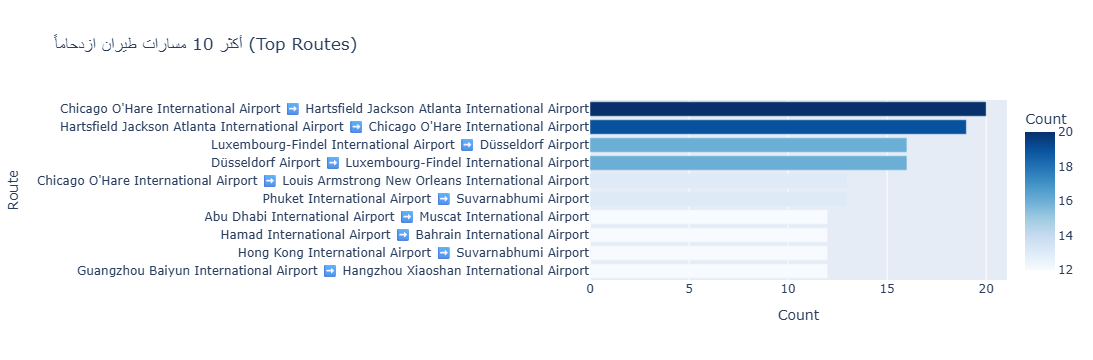

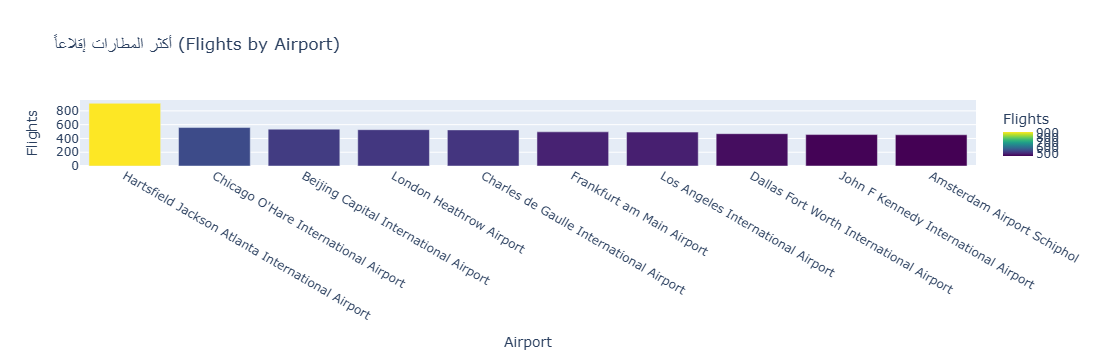

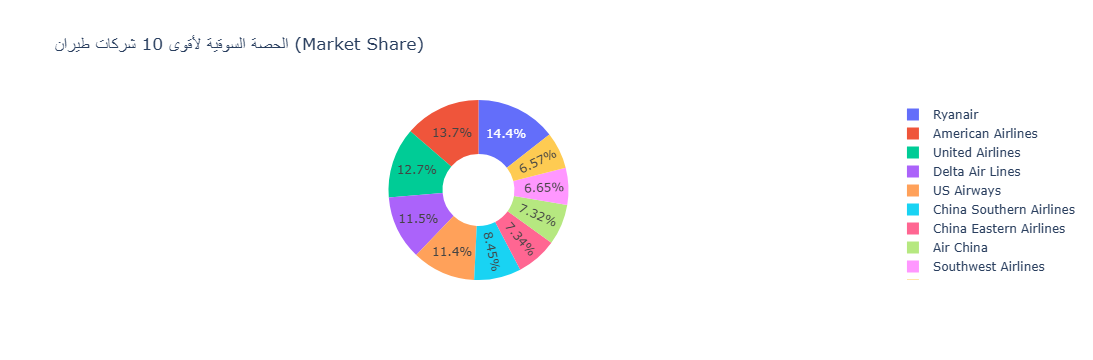

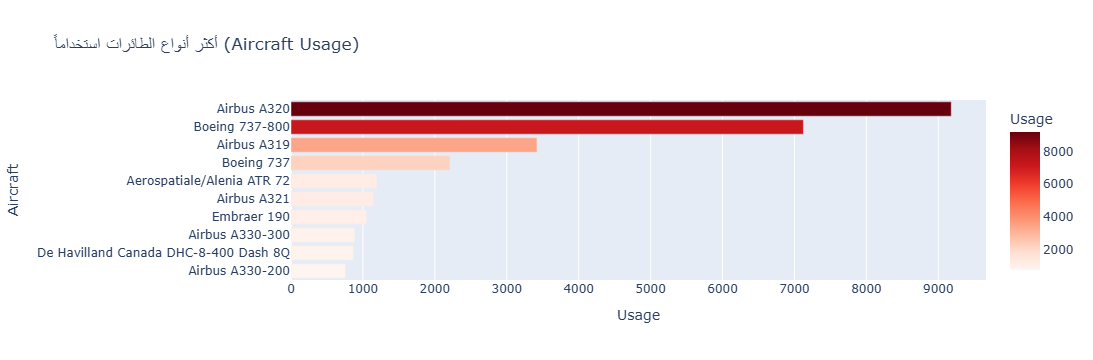

In [51]:

# 1. Top Routes (أكثر 10 مسارات استخداماً)
top_routes = full_data.groupby(['Source Airport', 'Dest Airport']).size().reset_index(name='Count').sort_values(by='Count', ascending=False).head(10)
top_routes['Route'] = top_routes['Source Airport'] + " ➡️ " + top_routes['Dest Airport']

fig1 = px.bar(top_routes, x='Count', y='Route', orientation='h',
              title='أكثر 10 مسارات طيران ازدحاماً (Top Routes)',
              color='Count', color_continuous_scale='Blues')
fig1.update_yaxes(autorange='reversed') # عشان الترتيب يكون من فوق لتحت
fig1.show()

# 2. Flights by Airport (أكثر 10 مطارات إقلاعاً)
top_airports = full_data['Source Airport'].value_counts().head(10).reset_index()
top_airports.columns = ['Airport', 'Flights']

fig2 = px.bar(top_airports, x='Airport', y='Flights',
              title='أكثر المطارات إقلاعاً (Flights by Airport)',
              color='Flights', color_continuous_scale='Viridis')
fig2.show()

# 3. Flights by Airline (أقوى 10 شركات طيران)
top_airlines = full_data['Airline Name'].value_counts().head(10).reset_index()
top_airlines.columns = ['Airline', 'Routes']

fig3 = px.pie(top_airlines, names='Airline', values='Routes', hole=0.4,
              title='الحصة السوقية لأقوى 10 شركات طيران (Market Share)')
fig3.show()

# 4. Aircraft Usage (أكثر الطائرات استخداماً)
top_aircrafts = full_data['Airplane Name'].value_counts().head(10).reset_index()
top_aircrafts.columns = ['Aircraft', 'Usage']

fig4 = px.bar(top_aircrafts, x='Usage', y='Aircraft', orientation='h',
              title='أكثر أنواع الطائرات استخداماً (Aircraft Usage)',
              color='Usage', color_continuous_scale='Reds')
fig4.update_yaxes(autorange='reversed')
fig4.show()

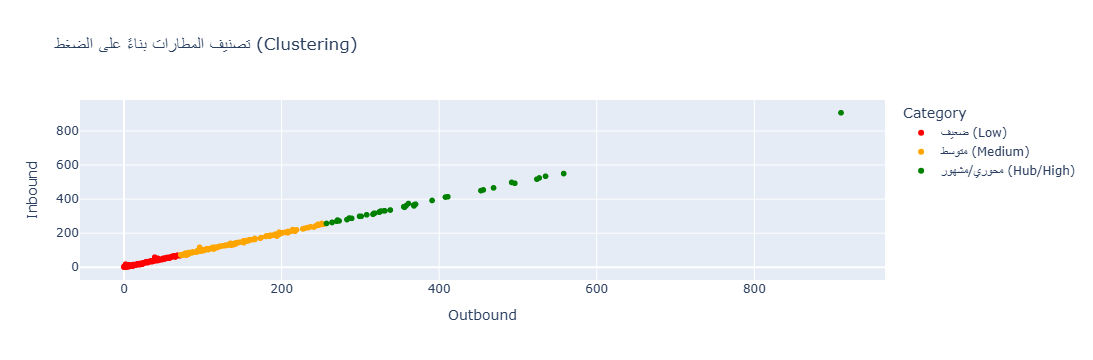

In [52]:
# تجميع داتا المطارات (إقلاع + استقبال)
source_traffic = full_data['Source Airport'].value_counts().reset_index()
source_traffic.columns = ['Airport', 'Outbound']

dest_traffic = full_data['Dest Airport'].value_counts().reset_index()
dest_traffic.columns = ['Airport', 'Inbound']

# دمجهم في جدول واحد للمطارات
airport_traffic = pd.merge(source_traffic, dest_traffic, on='Airport', how='outer').fillna(0)
airport_traffic['Total_Traffic'] = airport_traffic['Outbound'] + airport_traffic['Inbound']

# تطبيق خوارزمية K-Means لتقسيم المطارات لـ 3 مجموعات (Clusters)
kmeans = KMeans(n_clusters=3, random_state=42)
airport_traffic['Cluster'] = kmeans.fit_predict(airport_traffic[['Total_Traffic']])

# تسمية الـ Clusters عشان نفهمها
cluster_centers = kmeans.cluster_centers_.flatten()
sorted_centers = sorted(cluster_centers)
labels_map = {
    list(cluster_centers).index(sorted_centers[0]): 'ضعيف (Low)',
    list(cluster_centers).index(sorted_centers[1]): 'متوسط (Medium)',
    list(cluster_centers).index(sorted_centers[2]): 'محوري/مشهور (Hub/High)'
}
airport_traffic['Category'] = airport_traffic['Cluster'].map(labels_map)

# رسم النتيجة
fig_cluster = px.scatter(airport_traffic, x='Outbound', y='Inbound', color='Category',
                         hover_data=['Airport'], title='تصنيف المطارات بناءً على الضغط (Clustering)',
                         color_discrete_map={'ضعيف (Low)':'red', 'متوسط (Medium)':'orange', 'محوري/مشهور (Hub/High)':'green'})
fig_cluster.show()

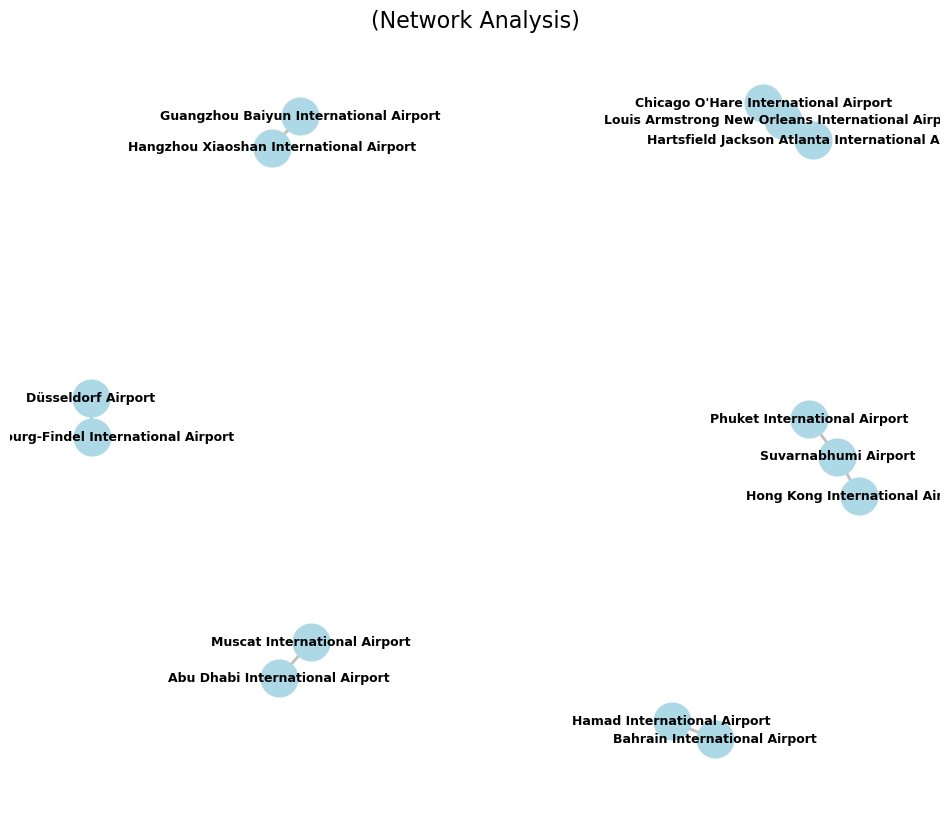

In [53]:
network_data = top_routes.head(50)

G = nx.from_pandas_edgelist(network_data, source='Source Airport', target='Dest Airport', edge_attr='Count')

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42) # طريقة توزيع النقط

# رسم النقط (المطارات) والخطوط (المسارات)
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue')
nx.draw_networkx_edges(G, pos, width=2, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=9, font_family='sans-serif', font_weight='bold')

plt.title('(Network Analysis)', fontsize=16)
plt.axis('off') # إخفاء المحاور
plt.show()

In [54]:
import pandas as pd

# ==============================
# KPIs
# ==============================
total_routes = len(full_data)

# لو عندك الأعمدة دي بنفس الاسم
total_airports = full_data[['Source airport', 'Destination airport']].nunique().sum()
total_airlines = full_data['Airline'].nunique()
total_airplanes = full_data['Equipment'].nunique()

kpis = pd.DataFrame({
    'Metric': ['Total Routes', 'Total Airports', 'Total Airlines', 'Total Airplanes'],
    'Value': [total_routes, total_airports, total_airlines, total_airplanes]
})

# ==============================
# تجهيز airplane usage
# ==============================
airplane_usage_df = airplane_usage.reset_index()
airplane_usage_df.columns = ['Airplane', 'Usage Count']

# ==============================
# تصدير كل حاجة في Excel
# ==============================
with pd.ExcelWriter("dashboard_ready_data.xlsx") as writer:
    
    # الداتا الأساسية
    full_data.to_excel(writer, sheet_name="Full Data", index=False)
    
    # التحليلات
    route_analysis.to_excel(writer, sheet_name="Route Analysis", index=False)
    airline_analysis.to_excel(writer, sheet_name="Airlines", index=True)
    airport_traffic.to_excel(writer, sheet_name="Airports Traffic", index=False)
    top_routes.to_excel(writer, sheet_name="Top Routes", index=False)
    airplane_usage_df.to_excel(writer, sheet_name="Airplanes", index=False)
    
    # KPIs
    kpis.to_excel(writer, sheet_name="KPIs", index=False)

print("✅ File exported successfully: dashboard_ready_data.xlsx")

✅ File exported successfully: dashboard_ready_data.xlsx
